# Supply Chain Analytics 

**Author:** Rishav Raj  
**Dataset:** [Olist Brazilian E-Commerce – Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)   
**Tools:** Python, Pandas, Matplotlib, Seaborn

---

This project analyzes supply chain and logistics data from Olist, a Brazilian e-commerce marketplace.  
The dataset covers around 100,000 orders placed between 2016 and 2018.

Main questions I'm looking at:
- How often do orders arrive late, and by how much?
- Which states have the worst delivery times?
- Does late delivery affect customer review scores?
- What's the split between seller processing time and carrier transit time?

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Libraries loaded')

Note: you may need to restart the kernel to use updated packages.
Libraries loaded


## 2. Load Data

In [2]:
import os
import pathlib

DATA_DIR = pathlib.Path('/Users/rishavraj/Desktop/Olist Project-11')  

orders      = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv')
customers   = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
order_items = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')
sellers     = pd.read_csv(DATA_DIR / 'olist_sellers_dataset.csv')
products    = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
reviews     = pd.read_csv(DATA_DIR / 'olist_order_reviews_dataset.csv')
payments    = pd.read_csv(DATA_DIR / 'olist_order_payments_dataset.csv')

print('orders:     ', orders.shape)
print('customers:  ', customers.shape)
print('order_items:', order_items.shape)
print('sellers:    ', sellers.shape)
print('products:   ', products.shape)
print('reviews:    ', reviews.shape)
print('payments:   ', payments.shape)

orders:      (99441, 8)
customers:   (99441, 5)
order_items: (112650, 7)
sellers:     (3095, 4)
products:    (32951, 9)
reviews:     (99224, 7)
payments:    (103886, 5)


In [3]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [4]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

## 3. Data Cleaning

Filter to delivered orders only — timestamp columns are empty for other statuses.

In [5]:
# Keep only delivered orders
delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f'Delivered orders: {len(delivered):,}')

# Convert timestamp columns
time_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in time_cols:
    delivered[col] = pd.to_datetime(delivered[col])

print('Done')

Delivered orders: 96,478
Done


## 4. Feature Engineering

In [6]:
# Delivery time metrics (in days)
delivered['actual_delivery_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']
).dt.total_seconds() / 86400

delivered['estimated_delivery_days'] = (
    delivered['order_estimated_delivery_date'] - delivered['order_purchase_timestamp']
).dt.total_seconds() / 86400

delivered['delay_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']
).dt.total_seconds() / 86400

delivered['seller_processing_days'] = (
    delivered['order_delivered_carrier_date'] - delivered['order_purchase_timestamp']
).dt.total_seconds() / 86400

delivered['carrier_transit_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_delivered_carrier_date']
).dt.total_seconds() / 86400

# Late flag (positive delay = late)
delivered['is_late'] = (delivered['delay_days'] > 0).astype(int)

# Order month for trend charts
delivered['order_month'] = delivered['order_purchase_timestamp'].dt.to_period('M').astype(str)
delivered['order_hour']  = delivered['order_purchase_timestamp'].dt.hour
delivered['order_dow']   = delivered['order_purchase_timestamp'].dt.day_name()

# Drop rows with missing time values
delivered = delivered.dropna(subset=['actual_delivery_days', 'delay_days'])
delivered = delivered[delivered['actual_delivery_days'] > 0]

print(f'Orders after cleaning: {len(delivered):,}')
print(f'Delay rate: {delivered["is_late"].mean():.1%}')
print(f'Avg delivery: {delivered["actual_delivery_days"].mean():.1f} days')

Orders after cleaning: 96,470
Delay rate: 8.1%
Avg delivery: 12.6 days


## 5. Merge All Tables

In [7]:
# Aggregate items per order
items_agg = order_items.groupby('order_id').agg(
    total_price   = ('price', 'sum'),
    total_freight = ('freight_value', 'sum'),
    n_items       = ('order_item_id', 'count'),
    seller_id     = ('seller_id', 'first'),
    product_id    = ('product_id', 'first')
).reset_index()

df = delivered.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')
df = df.merge(items_agg, on='order_id', how='left')
df = df.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
df = df.merge(products[['product_id', 'product_category_name', 'product_weight_g']], on='product_id', how='left')
df = df.merge(reviews[['order_id', 'review_score']].drop_duplicates('order_id'), on='order_id', how='left')
df = df.merge(payments[['order_id', 'payment_type', 'payment_installments', 'payment_value']].drop_duplicates('order_id'), on='order_id', how='left')

df['order_value']   = df['total_price'] + df['total_freight']
df['freight_ratio'] = df['total_freight'] / df['order_value'].replace(0, np.nan)
df['same_state']    = (df['seller_state'] == df['customer_state']).astype(int)

print(f'Final shape: {df.shape}')

Final shape: (96470, 33)


## 6. Order Volume Over Time

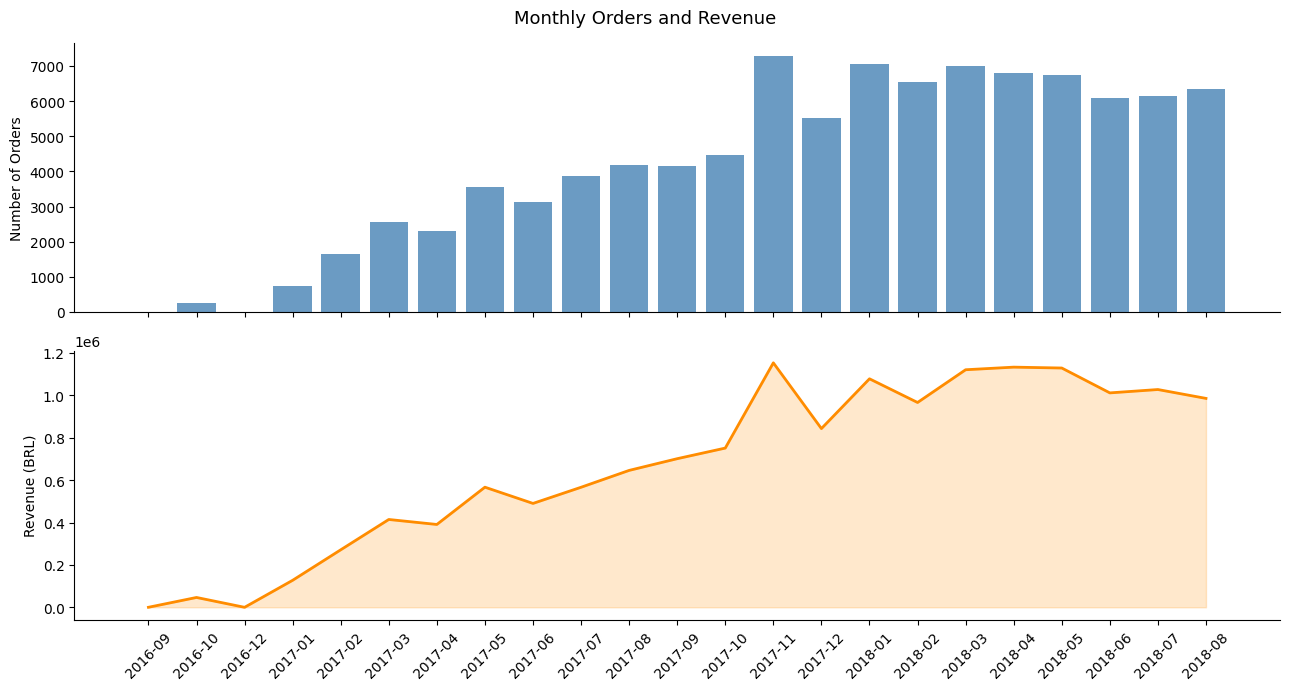

In [8]:
monthly = (
    df.groupby('order_month')
    .agg(orders=('order_id', 'count'), revenue=('order_value', 'sum'))
    .reset_index()
    .sort_values('order_month')
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle('Monthly Orders and Revenue', fontsize=13)

ax1.bar(monthly['order_month'], monthly['orders'], color='steelblue', alpha=0.8)
ax1.set_ylabel('Number of Orders')
ax1.tick_params(axis='x', rotation=45)

ax2.plot(monthly['order_month'], monthly['revenue'], color='darkorange', linewidth=2)
ax2.fill_between(monthly['order_month'], monthly['revenue'], color='darkorange', alpha=0.2)
ax2.set_ylabel('Revenue (BRL)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Delivery Time Distribution

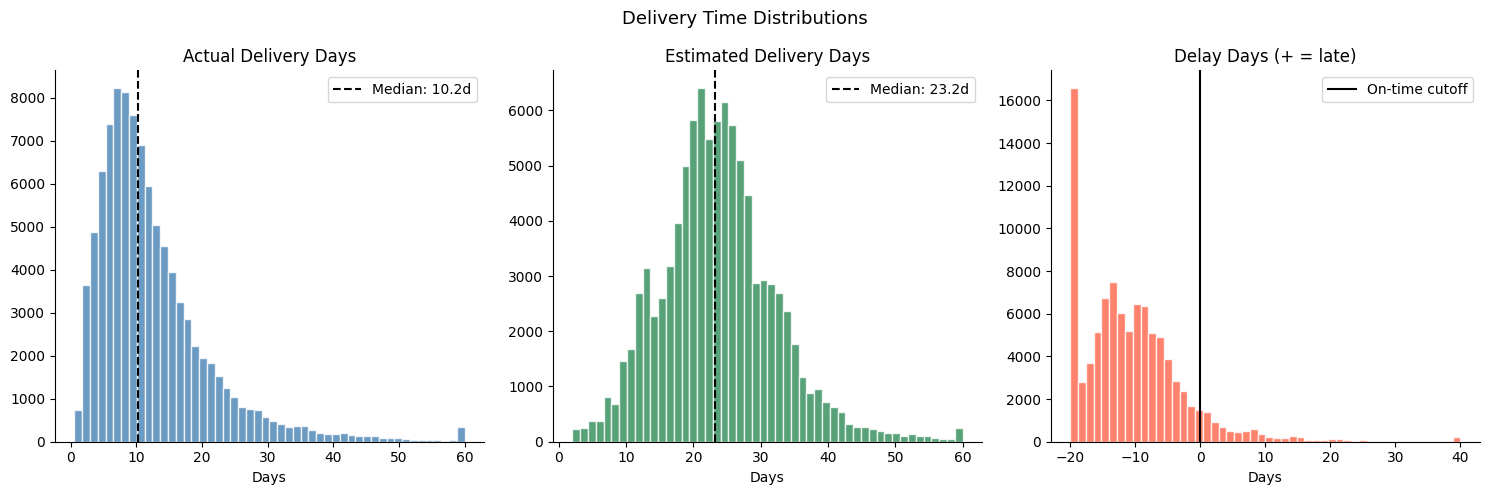

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Delivery Time Distributions', fontsize=13)

axes[0].hist(df['actual_delivery_days'].clip(0, 60), bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(df['actual_delivery_days'].median(), color='black', linestyle='--', linewidth=1.5,
                label=f'Median: {df["actual_delivery_days"].median():.1f}d')
axes[0].set_title('Actual Delivery Days')
axes[0].set_xlabel('Days')
axes[0].legend()

axes[1].hist(df['estimated_delivery_days'].clip(0, 60), bins=50, color='seagreen', alpha=0.8, edgecolor='white')
axes[1].axvline(df['estimated_delivery_days'].median(), color='black', linestyle='--', linewidth=1.5,
                label=f'Median: {df["estimated_delivery_days"].median():.1f}d')
axes[1].set_title('Estimated Delivery Days')
axes[1].set_xlabel('Days')
axes[1].legend()

axes[2].hist(df['delay_days'].clip(-20, 40), bins=50, color='tomato', alpha=0.8, edgecolor='white')
axes[2].axvline(0, color='black', linestyle='-', linewidth=1.5, label='On-time cutoff')
axes[2].set_title('Delay Days (+ = late)')
axes[2].set_xlabel('Days')
axes[2].legend()

plt.tight_layout()
plt.show()

## 8. Delivery Performance by State

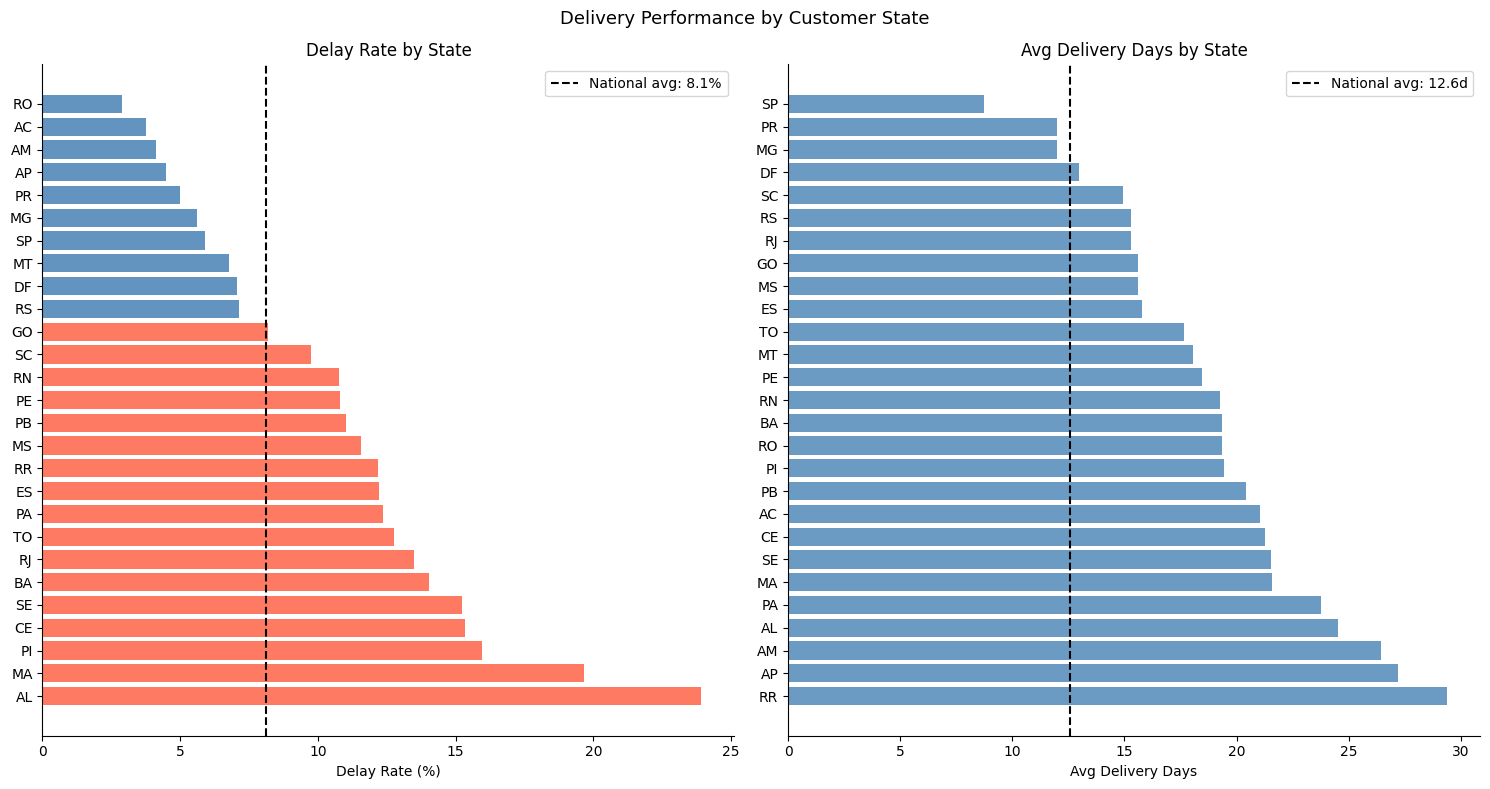

In [10]:
state_perf = (
    df.groupby('customer_state')
    .agg(
        orders       = ('order_id', 'count'),
        delay_rate   = ('is_late', 'mean'),
        avg_delivery = ('actual_delivery_days', 'mean')
    )
    .reset_index()
    .sort_values('delay_rate', ascending=False)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
fig.suptitle('Delivery Performance by Customer State', fontsize=13)

national_delay = df['is_late'].mean()
colors = ['tomato' if x > national_delay else 'steelblue' for x in state_perf['delay_rate']]

ax1.barh(state_perf['customer_state'], state_perf['delay_rate'] * 100, color=colors, alpha=0.85)
ax1.axvline(national_delay * 100, color='black', linestyle='--', linewidth=1.5,
            label=f'National avg: {national_delay*100:.1f}%')
ax1.set_xlabel('Delay Rate (%)')
ax1.set_title('Delay Rate by State')
ax1.legend()

state_sorted = state_perf.sort_values('avg_delivery', ascending=False)
ax2.barh(state_sorted['customer_state'], state_sorted['avg_delivery'], color='steelblue', alpha=0.8)
ax2.axvline(df['actual_delivery_days'].mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'National avg: {df["actual_delivery_days"].mean():.1f}d')
ax2.set_xlabel('Avg Delivery Days')
ax2.set_title('Avg Delivery Days by State')
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Review Scores vs Delivery Timing

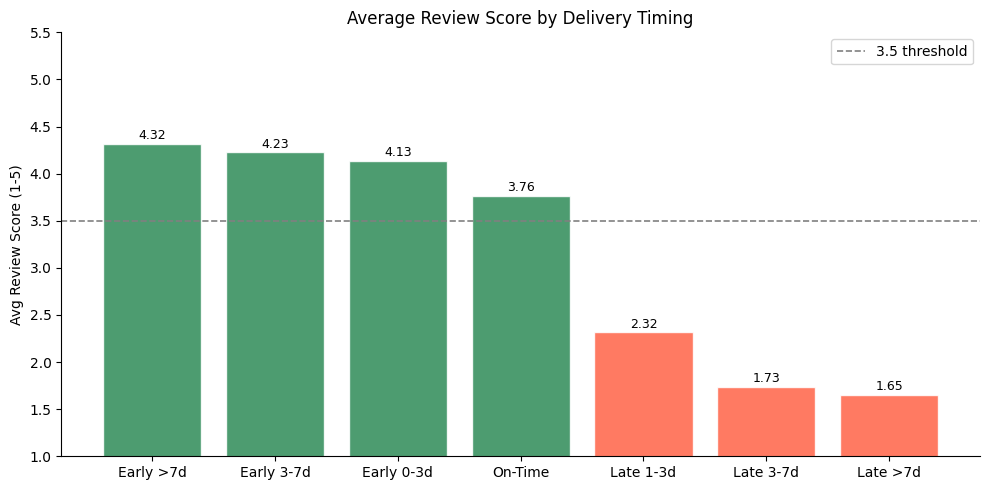

In [11]:
review_df = df.dropna(subset=['review_score']).copy()

review_df['delay_bucket'] = pd.cut(
    review_df['delay_days'],
    bins=[-60, -7, -3, 0, 3, 7, 15, 60],
    labels=['Early >7d', 'Early 3-7d', 'Early 0-3d', 'On-Time', 'Late 1-3d', 'Late 3-7d', 'Late >7d']
)

bucket_scores = (
    review_df.groupby('delay_bucket', observed=True)['review_score']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['seagreen'] * 4 + ['tomato'] * 3
bars = ax.bar(bucket_scores['delay_bucket'], bucket_scores['review_score'],
              color=colors, alpha=0.85, edgecolor='white')
ax.axhline(3.5, color='grey', linestyle='--', linewidth=1.2, label='3.5 threshold')
ax.set_ylim(1, 5.5)
ax.set_ylabel('Avg Review Score (1-5)')
ax.set_title('Average Review Score by Delivery Timing')
ax.legend()

for bar, val in zip(bars, bucket_scores['review_score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 10. Seller Processing vs Carrier Transit Time

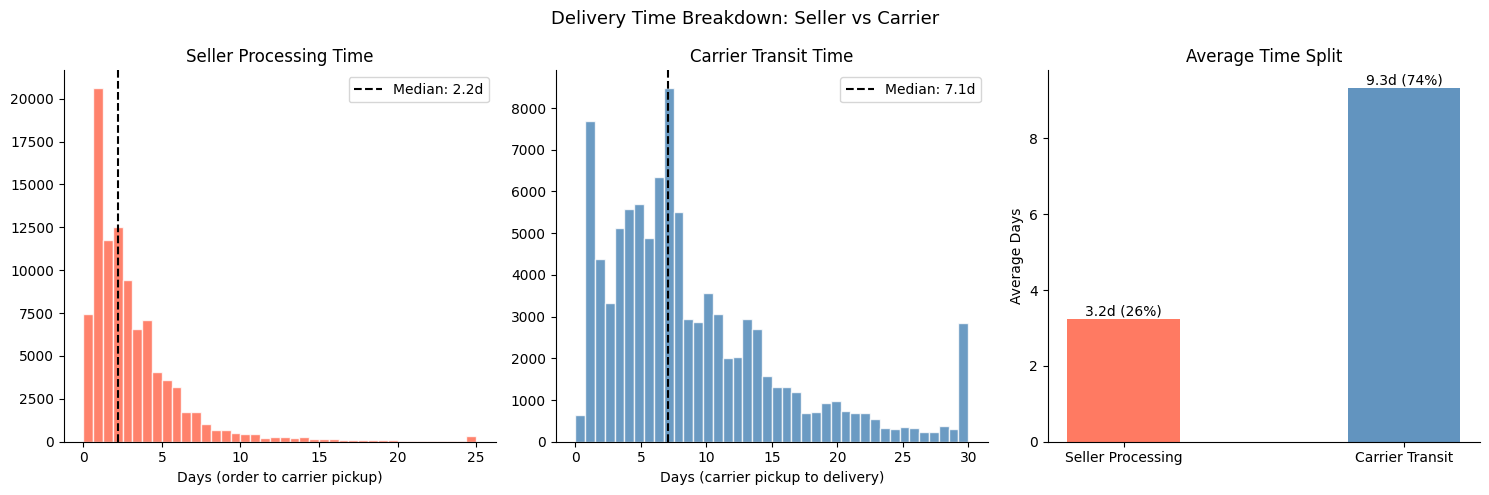

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Delivery Time Breakdown: Seller vs Carrier', fontsize=13)

proc = df['seller_processing_days'].clip(0, 25).dropna()
axes[0].hist(proc, bins=40, color='tomato', alpha=0.8, edgecolor='white')
axes[0].axvline(proc.median(), color='black', linestyle='--', linewidth=1.5,
                label=f'Median: {proc.median():.1f}d')
axes[0].set_title('Seller Processing Time')
axes[0].set_xlabel('Days (order to carrier pickup)')
axes[0].legend()

transit = df['carrier_transit_days'].clip(0, 30).dropna()
axes[1].hist(transit, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(transit.median(), color='black', linestyle='--', linewidth=1.5,
                label=f'Median: {transit.median():.1f}d')
axes[1].set_title('Carrier Transit Time')
axes[1].set_xlabel('Days (carrier pickup to delivery)')
axes[1].legend()

avg_proc    = df['seller_processing_days'].mean()
avg_transit = df['carrier_transit_days'].mean()
total       = avg_proc + avg_transit

axes[2].bar(['Seller Processing', 'Carrier Transit'], [avg_proc, avg_transit],
            color=['tomato', 'steelblue'], alpha=0.85, width=0.4)
axes[2].set_ylabel('Average Days')
axes[2].set_title('Average Time Split')
for i, val in enumerate([avg_proc, avg_transit]):
    axes[2].text(i, val + 0.1, f'{val:.1f}d ({val/total*100:.0f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 11. Order Heatmap — Day and Hour

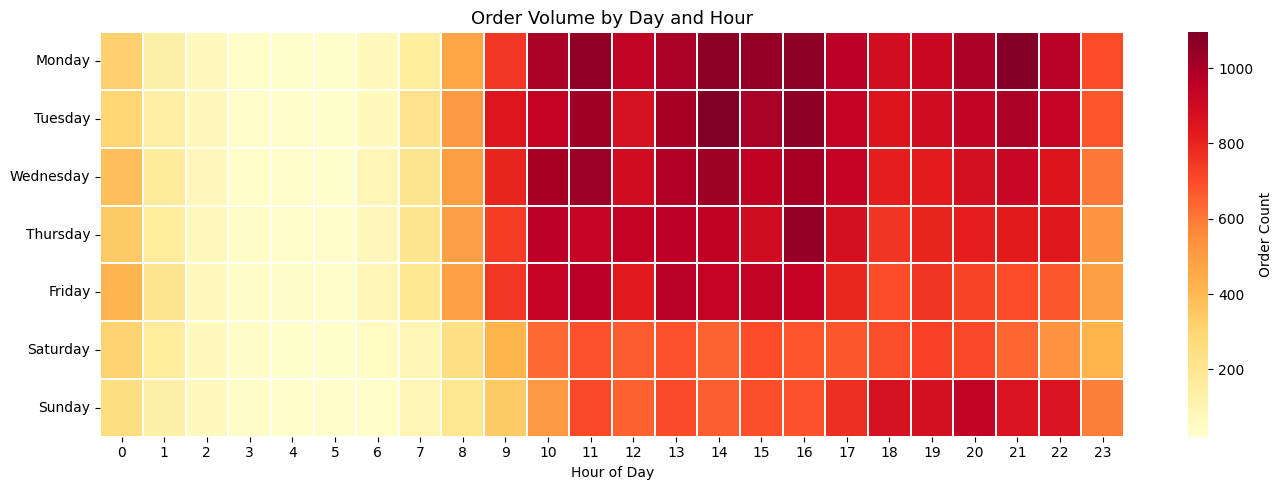

In [13]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = (
    df.groupby(['order_dow', 'order_hour'])['order_id']
    .count()
    .reset_index()
    .pivot(index='order_dow', columns='order_hour', values='order_id')
    .reindex(dow_order)
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3, cbar_kws={'label': 'Order Count'})
ax.set_title('Order Volume by Day and Hour', fontsize=13)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 12. Top Product Categories

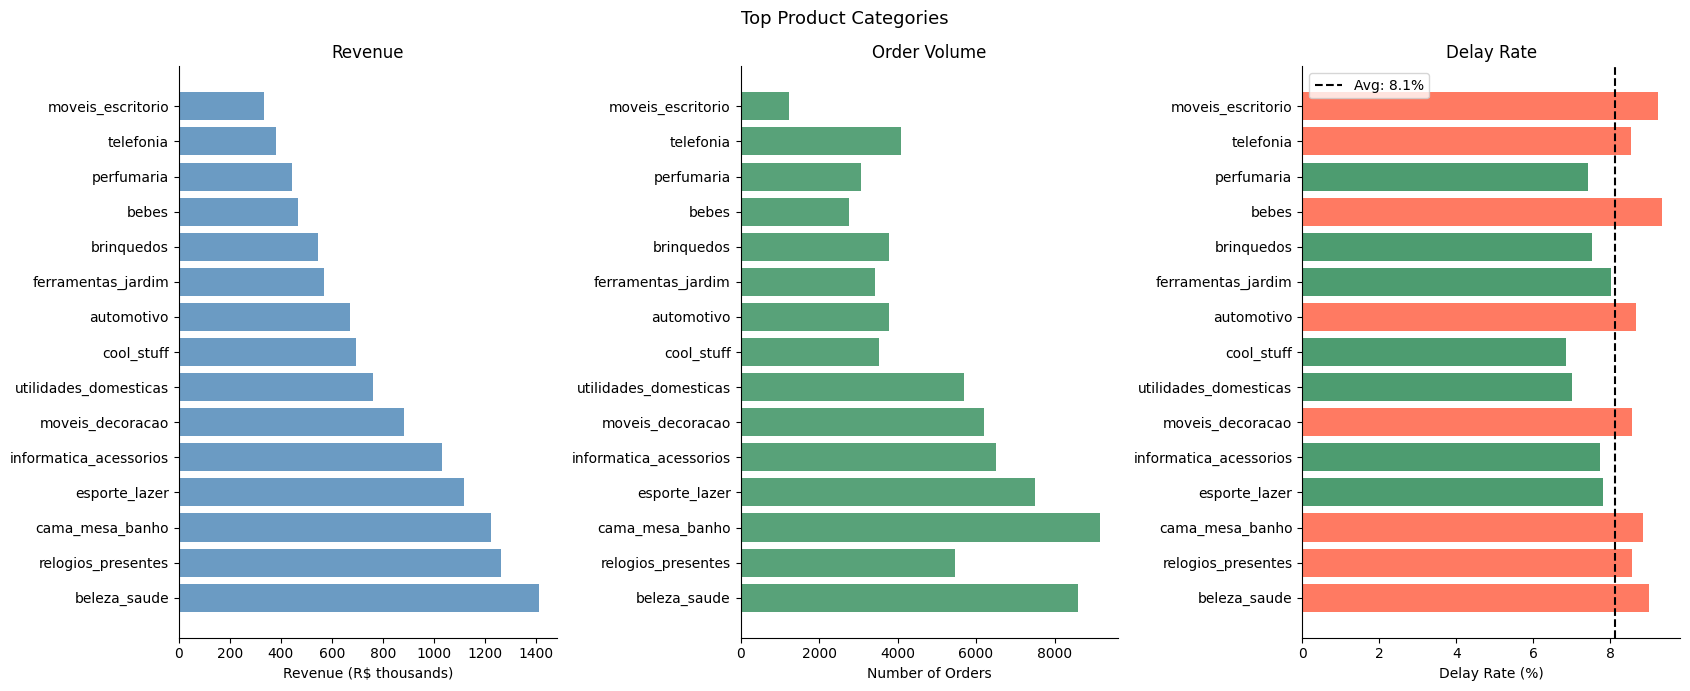

In [14]:
cat_df = (
    df.dropna(subset=['product_category_name'])
    .groupby('product_category_name')
    .agg(
        orders     = ('order_id', 'count'),
        revenue    = ('order_value', 'sum'),
        delay_rate = ('is_late', 'mean')
    )
    .query('orders > 200')
    .sort_values('revenue', ascending=False)
    .head(15)
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(17, 7))
fig.suptitle('Top Product Categories', fontsize=13)

axes[0].barh(cat_df['product_category_name'], cat_df['revenue'] / 1000, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Revenue (R$ thousands)')
axes[0].set_title('Revenue')

axes[1].barh(cat_df['product_category_name'], cat_df['orders'], color='seagreen', alpha=0.8)
axes[1].set_xlabel('Number of Orders')
axes[1].set_title('Order Volume')

avg_delay = df['is_late'].mean()
colors = ['tomato' if x > avg_delay else 'seagreen' for x in cat_df['delay_rate']]
axes[2].barh(cat_df['product_category_name'], cat_df['delay_rate'] * 100, color=colors, alpha=0.85)
axes[2].axvline(avg_delay * 100, color='black', linestyle='--', linewidth=1.5,
                label=f'Avg: {avg_delay*100:.1f}%')
axes[2].set_xlabel('Delay Rate (%)')
axes[2].set_title('Delay Rate')
axes[2].legend()

plt.tight_layout()
plt.show()

## 13. Freight Cost Analysis

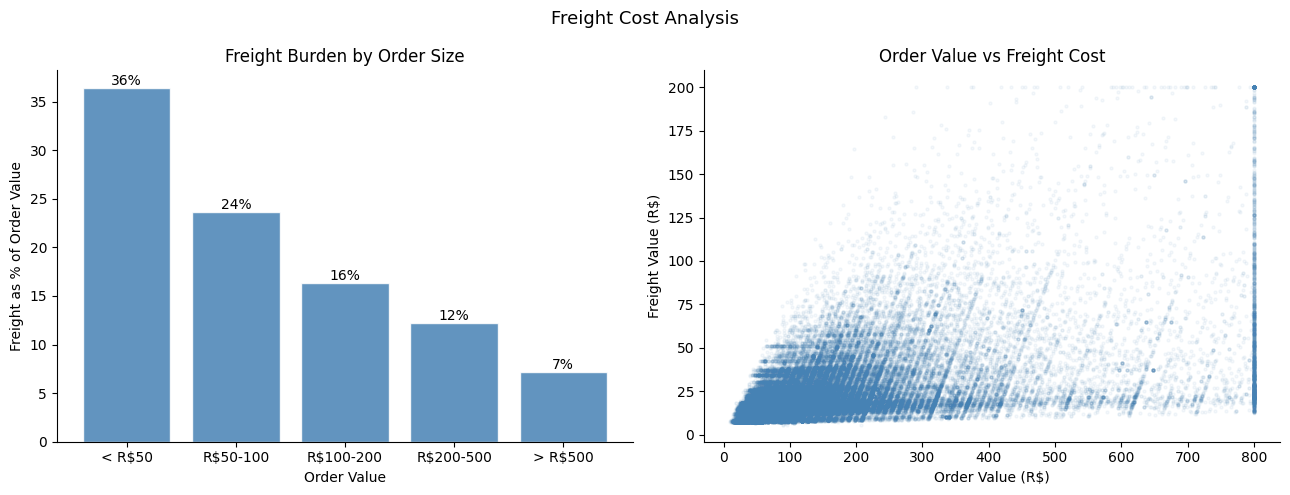

In [15]:
freight_df = df.dropna(subset=['freight_ratio']).copy()
freight_df = freight_df[freight_df['freight_ratio'].between(0.01, 1.5)]

freight_df['order_value_bucket'] = pd.cut(
    freight_df['order_value'],
    bins=[0, 50, 100, 200, 500, 15000],
    labels=['< R$50', 'R$50-100', 'R$100-200', 'R$200-500', '> R$500']
)

fb = freight_df.groupby('order_value_bucket', observed=True)['freight_ratio'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Freight Cost Analysis', fontsize=13)

axes[0].bar(fb['order_value_bucket'], fb['freight_ratio'] * 100, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Order Value')
axes[0].set_ylabel('Freight as % of Order Value')
axes[0].set_title('Freight Burden by Order Size')
for bar, val in zip(axes[0].patches, fb['freight_ratio']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val*100:.0f}%', ha='center', fontsize=10)

axes[1].scatter(freight_df['order_value'].clip(0, 800), freight_df['total_freight'].clip(0, 200),
                alpha=0.05, s=5, color='steelblue')
axes[1].set_xlabel('Order Value (R$)')
axes[1].set_ylabel('Freight Value (R$)')
axes[1].set_title('Order Value vs Freight Cost')

plt.tight_layout()
plt.show()

## 14. Payment Behaviour

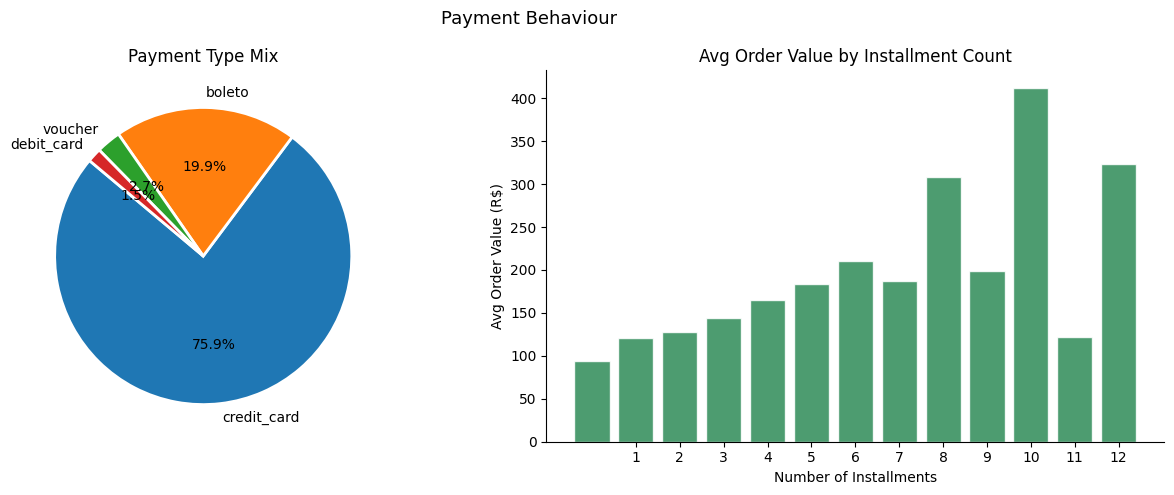

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Payment Behaviour', fontsize=13)

ptype = df['payment_type'].value_counts()
axes[0].pie(ptype.values, labels=ptype.index, autopct='%1.1f%%',
            wedgeprops={'linewidth': 2, 'edgecolor': 'white'}, startangle=140)
axes[0].set_title('Payment Type Mix')

inst = (
    df.groupby('payment_installments')['order_value']
    .mean().reset_index()
    .query('payment_installments <= 12')
)
axes[1].bar(inst['payment_installments'], inst['order_value'], color='seagreen', alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Number of Installments')
axes[1].set_ylabel('Avg Order Value (R$)')
axes[1].set_title('Avg Order Value by Installment Count')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

## 15. Correlation Matrix

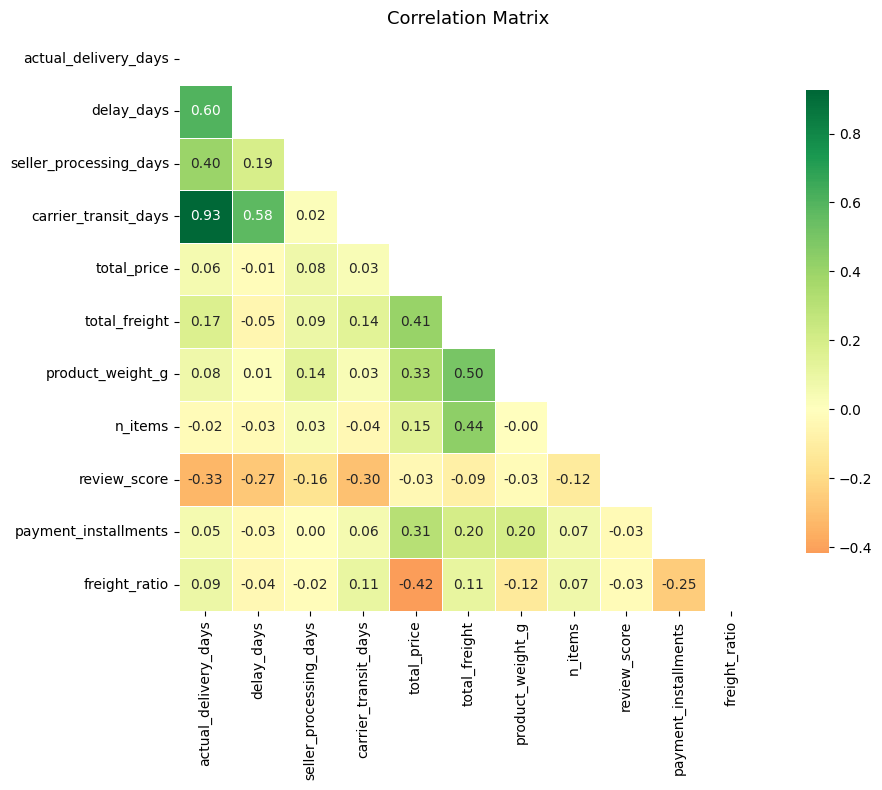

In [17]:
corr_cols = [
    'actual_delivery_days', 'delay_days', 'seller_processing_days',
    'carrier_transit_days', 'total_price', 'total_freight',
    'product_weight_g', 'n_items', 'review_score',
    'payment_installments', 'freight_ratio'
]

corr = df[corr_cols].dropna().corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 16. Delay Analysis — Key Factors

In [18]:
# Same-state vs cross-state delay rates
print('Same-State vs Cross-State Delay:')
print(
    df.groupby('same_state')['is_late']
    .agg(['mean', 'count'])
    .rename(index={0: 'Cross-State', 1: 'Same-State'})
    .assign(delay_pct=lambda x: (x['mean'] * 100).round(1))
    [['count', 'delay_pct']]
)

print()

# Delay rate by product weight
df['weight_bucket'] = pd.cut(
    df['product_weight_g'],
    bins=[0, 500, 2000, 5000, 10000, 30001],
    labels=['< 500g', '0.5-2kg', '2-5kg', '5-10kg', '> 10kg']
)

print('Delay Rate by Product Weight:')
print(
    df.groupby('weight_bucket', observed=True)['is_late']
    .agg(['mean', 'count'])
    .assign(delay_pct=lambda x: (x['mean'] * 100).round(1))
    [['count', 'delay_pct']]
)

print()

# Delay rate by seller processing speed quartile
df['proc_quartile'] = pd.qcut(
    df['seller_processing_days'].clip(0, 20), q=4,
    labels=['Q1 Fastest', 'Q2', 'Q3', 'Q4 Slowest']
)

print('Delay Rate by Seller Processing Speed:')
print(
    df.groupby('proc_quartile', observed=True)['is_late']
    .agg(['mean', 'count'])
    .assign(delay_pct=lambda x: (x['mean'] * 100).round(1))
    [['count', 'delay_pct']]
)

Same-State vs Cross-State Delay:
             count  delay_pct
same_state                   
Cross-State  61769        9.3
Same-State   34701        6.1

Delay Rate by Product Weight:
               count  delay_pct
weight_bucket                  
< 500g         40911        7.7
0.5-2kg        33600        8.0
2-5kg           9960        8.6
5-10kg          7511        8.1
> 10kg          4463       11.0

Delay Rate by Seller Processing Speed:
               count  delay_pct
proc_quartile                  
Q1 Fastest     24118        4.4
Q2             24117        6.3
Q3             24117        7.5
Q4 Slowest     24117       14.2


## 17. Summary

Key findings from this analysis:

1. **Delay rate is around 8% nationally**, but northern states (AM, AP, RR, PA) run 12-18%.

2. **Average delivery is ~12 days**, but estimated delivery is set to ~20 days — Olist builds in a big buffer.

3. **Late deliveries strongly hurt review scores.** On-time orders average 4.1-4.3 stars. Orders more than 7 days late drop below 3 stars.

4. **Cross-state orders are significantly more likely to be late** than same-state orders.

5. **Seller processing accounts for ~35-40% of total delivery time** — this is within the platform's control and is a high-impact area to improve.

6. **Small orders (< R$50) pay 30-40% of order value as freight**, which is a big issue for checkout conversion.

7. Heavier products and multi-item orders show higher delay rates.

---
**Rishav Raj**   
Skills: Python - SQL - Power BI - Tableau - MS Excel  
[LinkedIn](https://www.linkedin.com/in/rishav-raj-7a6544362/) | [GitHub](https://github.com/rishav-raj-01)